In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_dataset = datasets.ImageFolder(
    root="/kaggle/input/shuvoolok/raf-db-dataset/DATASET/test",
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Number of test images:", len(test_dataset))
print("Classes:", test_dataset.classes)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/shuvoolok/raf-db-dataset/DATASET/test'

In [4]:
import os

dataset_root = "/kaggle/input/datasets/shuvoolok/raf-db-dataset"

for root, dirs, files in os.walk(dataset_root):
    print(root)
    
    # print only first few levels
    if len(root.split("/")) > 8:
        continue

In [5]:
import os

print(os.listdir("/kaggle/input/datasets/shuvoolok/raf-db-dataset"))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/shuvoolok/raf-db-dataset'

In [6]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [7]:
import os

print(os.listdir("/kaggle/input/datasets"))

['ankansamanta980', 'shuvoalok']


In [8]:
import os

print(os.listdir("/kaggle/input/datasets/shuvoalok"))

['raf-db-dataset']


In [9]:
import os

print(os.listdir("/kaggle/input/datasets/shuvoalok/raf-db-dataset"))

['test_labels.csv', 'DATASET', 'train_labels.csv']


In [10]:
import os

print(os.listdir("/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"))

['test', 'train']


In [11]:
import os

print(os.listdir("/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test"))

['7', '2', '5', '3', '1', '4', '6']


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_dataset = datasets.ImageFolder(
    root="/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test",
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Total Test Images:", len(test_dataset))
print("Classes:", test_dataset.classes)

Total Test Images: 3068
Classes: ['1', '2', '3', '4', '5', '6', '7']


In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [6]:
import torch

path = "/kaggle/input/datasets/ankansamanta980/scratch-model/efficientnet_scratch_rafdb.pth"

checkpoint = torch.load(path, map_location="cpu")

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nKeys:")
    print(checkpoint.keys())

<class 'collections.OrderedDict'>

Keys:
odict_keys(['stem.0.weight', 'stem.1.weight', 'stem.1.bias', 'stem.1.running_mean', 'stem.1.running_var', 'stem.1.num_batches_tracked', 'blocks.0.depthwise.0.weight', 'blocks.0.depthwise.1.weight', 'blocks.0.depthwise.1.bias', 'blocks.0.depthwise.1.running_mean', 'blocks.0.depthwise.1.running_var', 'blocks.0.depthwise.1.num_batches_tracked', 'blocks.0.se.fc1.weight', 'blocks.0.se.fc1.bias', 'blocks.0.se.fc2.weight', 'blocks.0.se.fc2.bias', 'blocks.0.project.0.weight', 'blocks.0.project.1.weight', 'blocks.0.project.1.bias', 'blocks.0.project.1.running_mean', 'blocks.0.project.1.running_var', 'blocks.0.project.1.num_batches_tracked', 'blocks.1.expand.0.weight', 'blocks.1.expand.1.weight', 'blocks.1.expand.1.bias', 'blocks.1.expand.1.running_mean', 'blocks.1.expand.1.running_var', 'blocks.1.expand.1.num_batches_tracked', 'blocks.1.depthwise.0.weight', 'blocks.1.depthwise.1.weight', 'blocks.1.depthwise.1.bias', 'blocks.1.depthwise.1.running_mean', '

In [7]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*12*12,256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        return self.fc(x)

cnn_model = CustomCNN(7)

state_dict = torch.load(
    "/kaggle/input/datasets/ankansamanta980/scratch-model/final_cnn.pth",
    map_location="cpu"
)

cnn_model.load_state_dict(state_dict)

print("CustomCNN Loaded Successfully")

CustomCNN Loaded Successfully


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNetScratch(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_c, out_c, blocks, stride=1):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = F.adaptive_avg_pool2d(x, (1,1))
        x = torch.flatten(x,1)

        x = self.dropout(x)

        return self.fc(x)

resnet_model = ResNetScratch(7)

state_dict = torch.load(
    "/kaggle/input/datasets/ankansamanta980/scratch-model/resnet50_rafdb.pth",
    map_location="cpu"
)

resnet_model.load_state_dict(state_dict)

print("ResNetScratch Loaded Successfully")

RuntimeError: Error(s) in loading state_dict for ResNetScratch:
	Missing key(s) in state_dict: "conv1.bias", "layer1.0.conv1.bias", "layer1.0.conv2.bias", "layer1.1.conv1.bias", "layer1.1.conv2.bias", "layer2.0.conv1.bias", "layer2.0.conv2.bias", "layer2.0.shortcut.0.weight", "layer2.0.shortcut.0.bias", "layer2.0.shortcut.1.weight", "layer2.0.shortcut.1.bias", "layer2.0.shortcut.1.running_mean", "layer2.0.shortcut.1.running_var", "layer2.1.conv1.bias", "layer2.1.conv2.bias", "layer3.0.conv1.bias", "layer3.0.conv2.bias", "layer3.0.shortcut.0.weight", "layer3.0.shortcut.0.bias", "layer3.0.shortcut.1.weight", "layer3.0.shortcut.1.bias", "layer3.0.shortcut.1.running_mean", "layer3.0.shortcut.1.running_var", "layer3.1.conv1.bias", "layer3.1.conv2.bias", "layer4.0.conv1.bias", "layer4.0.conv2.bias", "layer4.0.shortcut.0.weight", "layer4.0.shortcut.0.bias", "layer4.0.shortcut.1.weight", "layer4.0.shortcut.1.bias", "layer4.0.shortcut.1.running_mean", "layer4.0.shortcut.1.running_var", "layer4.

In [8]:
import torch

state_dict = torch.load(
    "/kaggle/input/datasets/ankansamanta980/scratch-model/resnet50_rafdb.pth",
    map_location="cpu"
)

print(list(state_dict.keys())[:20])

['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight']


In [9]:
import torch
import torch.nn as nn
from torchvision.models import resnet50

resnet_model = resnet50(weights=None)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    7
)

state_dict = torch.load(
    "/kaggle/input/datasets/ankansamanta980/scratch-model/resnet50_rafdb.pth",
    map_location="cpu"
)

resnet_model.load_state_dict(state_dict)

print("ResNet50 Loaded Successfully")

ResNet50 Loaded Successfully


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

def drop_connect(x, drop_prob, training):
    if not training or drop_prob == 0:
        return x
    keep_prob = 1 - drop_prob
    random_tensor = keep_prob + torch.rand(
        [x.shape[0],1,1,1],
        device=x.device
    )
    binary_mask = torch.floor(random_tensor)
    return x / keep_prob * binary_mask

class SEBlock(nn.Module):
    def __init__(self, in_c):
        super().__init__()
        self.fc1 = nn.Conv2d(in_c, in_c//4, 1)
        self.fc2 = nn.Conv2d(in_c//4, in_c, 1)

    def forward(self, x):
        y = F.adaptive_avg_pool2d(x,1)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))
        return x * y

class MBConv(nn.Module):
    def __init__(self, in_c, out_c, exp, stride, drop_rate):
        super().__init__()

        self.use_res = (in_c==out_c and stride==1)

        hidden = in_c * exp

        self.expand = nn.Sequential(
            nn.Conv2d(in_c, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden),
            Swish()
        ) if exp != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv2d(
                hidden,
                hidden,
                3,
                stride,
                1,
                groups=hidden,
                bias=False
            ),
            nn.BatchNorm2d(hidden),
            Swish()
        )

        self.se = SEBlock(hidden)

        self.project = nn.Sequential(
            nn.Conv2d(hidden, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        )

        self.drop_rate = drop_rate

    def forward(self, x):

        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res:
            out = drop_connect(
                out,
                self.drop_rate,
                self.training
            )
            return x + out

        return out

class EfficientNet_B0(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3,32,3,2,1,bias=False),
            nn.BatchNorm2d(32),
            Swish()
        )

        self.blocks = nn.Sequential(
            MBConv(32,16,1,1,0.2),

            MBConv(16,24,6,2,0.2),
            MBConv(24,24,6,1,0.2),

            MBConv(24,40,6,2,0.2),
            MBConv(40,40,6,1,0.2),

            MBConv(40,80,6,2,0.2),
            MBConv(80,80,6,1,0.2),
            MBConv(80,80,6,1,0.2),

            MBConv(80,112,6,1,0.2),
            MBConv(112,112,6,1,0.2),

            MBConv(112,192,6,2,0.2),
            MBConv(192,192,6,1,0.2),
            MBConv(192,192,6,1,0.2),

            MBConv(192,320,6,1,0.2),
        )

        self.head = nn.Sequential(
            nn.Conv2d(320,1280,1,bias=False),
            nn.BatchNorm2d(1280),
            Swish(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(1280, num_classes)

    def forward(self,x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        x = torch.flatten(x,1)
        x = self.dropout(x)
        return self.fc(x)

eff_model = EfficientNet_B0(7)

state_dict = torch.load(
    "/kaggle/input/datasets/ankansamanta980/scratch-model/efficientnet_scratch_rafdb.pth",
    map_location="cpu"
)

eff_model.load_state_dict(state_dict)

print("EfficientNet Loaded Successfully")

EfficientNet Loaded Successfully


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

cnn_transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

cnn_test_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test",
    transform=cnn_transform
)

cnn_test_loader = DataLoader(
    cnn_test_dataset,
    batch_size=32,
    shuffle=False
)

print("Test Images:", len(cnn_test_dataset))

Test Images: 3068


In [12]:
import numpy as np
import torch

cnn_model.eval()
cnn_model = cnn_model.to(device)

cnn_probs = []
true_labels = []

with torch.no_grad():

    for images, labels in cnn_test_loader:

        images = images.to(device)

        outputs = cnn_model(images)

        probs = torch.softmax(outputs, dim=1)

        cnn_probs.extend(probs.cpu().numpy())
        true_labels.extend(labels.numpy())

cnn_probs = np.array(cnn_probs)
true_labels = np.array(true_labels)

print(cnn_probs.shape)
print(true_labels.shape)

(3068, 7)
(3068,)


In [13]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

resnet_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

resnet_test_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test",
    transform=resnet_transform
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=32,
    shuffle=False
)

print("Test Images:", len(resnet_test_dataset))

Test Images: 3068


In [14]:
import numpy as np
import torch

resnet_model.eval()
resnet_model = resnet_model.to(device)

resnet_probs = []

with torch.no_grad():

    for images, labels in resnet_test_loader:

        images = images.to(device)

        outputs = resnet_model(images)

        probs = torch.softmax(outputs, dim=1)

        resnet_probs.extend(probs.cpu().numpy())

resnet_probs = np.array(resnet_probs)

print(resnet_probs.shape)

(3068, 7)


In [15]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

eff_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

eff_test_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test",
    transform=eff_transform
)

eff_test_loader = DataLoader(
    eff_test_dataset,
    batch_size=32,
    shuffle=False
)

print("Test Images:", len(eff_test_dataset))

Test Images: 3068


In [16]:
import numpy as np
import torch

eff_model.eval()
eff_model = eff_model.to(device)

eff_probs = []

with torch.no_grad():

    for images, labels in eff_test_loader:

        images = images.to(device)

        outputs = eff_model(images)

        probs = torch.softmax(outputs, dim=1)

        eff_probs.extend(probs.cpu().numpy())

eff_probs = np.array(eff_probs)

print(eff_probs.shape)

(3068, 7)


In [17]:
from collections import defaultdict
import numpy as np

def probs_to_bba(probs):
    return {
        frozenset([i]): float(prob)
        for i, prob in enumerate(probs)
    }

def orthogonal_sum(m1, m2):

    result = defaultdict(float)
    conflict = 0.0

    for A, a_val in m1.items():

        for B, b_val in m2.items():

            inter = A & B

            mass = a_val * b_val

            if inter:
                result[inter] += mass
            else:
                conflict += mass

    if conflict >= 1.0:
        return None

    for key in result:
        result[key] /= (1.0 - conflict)

    return dict(result)

In [18]:
correct = 0
total = len(true_labels)

for i in range(total):

    m1 = probs_to_bba(cnn_probs[i])
    m2 = probs_to_bba(resnet_probs[i])

    fused = orthogonal_sum(m1, m2)

    if fused is None:
        continue

    fused_probs = np.array([
        fused.get(frozenset([j]), 0)
        for j in range(7)
    ])

    pred = np.argmax(fused_probs)

    if pred == true_labels[i]:
        correct += 1

cnn_resnet_dst_acc = correct / total

print("CNN + ResNet50 DST Accuracy:",
      round(cnn_resnet_dst_acc * 100, 2), "%")

CNN + ResNet50 DST Accuracy: 82.14 %


In [19]:
correct = 0
total = len(true_labels)

for i in range(total):

    m1 = probs_to_bba(cnn_probs[i])
    m2 = probs_to_bba(eff_probs[i])

    fused = orthogonal_sum(m1, m2)

    if fused is None:
        continue

    fused_probs = np.array([
        fused.get(frozenset([j]), 0)
        for j in range(7)
    ])

    pred = np.argmax(fused_probs)

    if pred == true_labels[i]:
        correct += 1

cnn_eff_dst_acc = correct / total

print("CNN + EfficientNet DST Accuracy:",
      round(cnn_eff_dst_acc * 100, 2), "%")

CNN + EfficientNet DST Accuracy: 83.41 %


In [20]:
correct = 0
total = len(true_labels)

for i in range(total):

    m1 = probs_to_bba(resnet_probs[i])
    m2 = probs_to_bba(eff_probs[i])

    fused = orthogonal_sum(m1, m2)

    if fused is None:
        continue

    fused_probs = np.array([
        fused.get(frozenset([j]), 0)
        for j in range(7)
    ])

    pred = np.argmax(fused_probs)

    if pred == true_labels[i]:
        correct += 1

resnet_eff_dst_acc = correct / total

print(
    "ResNet50 + EfficientNet DST Accuracy:",
    round(resnet_eff_dst_acc * 100, 2),
    "%"
)

ResNet50 + EfficientNet DST Accuracy: 83.05 %


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Fusion Pair": [
        "CustomCNN + ResNet50",
        "CustomCNN + EfficientNet",
        "ResNet50 + EfficientNet"
    ],
    "DST Accuracy (%)": [
        round(cnn_resnet_dst_acc * 100, 2),
        round(cnn_eff_dst_acc * 100, 2),
        round(resnet_eff_dst_acc * 100, 2)
    ]
})

results = results.sort_values(
    by="DST Accuracy (%)",
    ascending=False
)

print(results)

                Fusion Pair  DST Accuracy (%)
1  CustomCNN + EfficientNet             83.41
2   ResNet50 + EfficientNet             83.05
0      CustomCNN + ResNet50             82.14


In [22]:
import numpy as np

cnn_acc = np.mean(np.argmax(cnn_probs, axis=1) == true_labels)
resnet_acc = np.mean(np.argmax(resnet_probs, axis=1) == true_labels)
eff_acc = np.mean(np.argmax(eff_probs, axis=1) == true_labels)

print("CustomCNN Accuracy      :", round(cnn_acc*100,2), "%")
print("ResNet50 Accuracy       :", round(resnet_acc*100,2), "%")
print("EfficientNet Accuracy   :", round(eff_acc*100,2), "%")

CustomCNN Accuracy      : 81.23 %
ResNet50 Accuracy       : 79.14 %
EfficientNet Accuracy   : 81.62 %


In [23]:
correct = 0
total = len(true_labels)

for i in range(total):

    m1 = probs_to_bba(cnn_probs[i])
    m2 = probs_to_bba(resnet_probs[i])
    m3 = probs_to_bba(eff_probs[i])

    fused12 = orthogonal_sum(m1, m2)

    if fused12 is None:
        continue

    fused123 = orthogonal_sum(fused12, m3)

    if fused123 is None:
        continue

    fused_probs = np.array([
        fused123.get(frozenset([j]), 0)
        for j in range(7)
    ])

    pred = np.argmax(fused_probs)

    if pred == true_labels[i]:
        correct += 1

dst3_acc = correct / total

print(
    "CNN + ResNet50 + EfficientNet DST Accuracy:",
    round(dst3_acc * 100, 2),
    "%"
)

CNN + ResNet50 + EfficientNet DST Accuracy: 83.83 %


In [24]:
import pandas as pd

final_results = pd.DataFrame({
    "Method": [
        "CustomCNN",
        "ResNet50",
        "EfficientNet",
        "DST (CustomCNN + ResNet50)",
        "DST (CustomCNN + EfficientNet)",
        "DST (ResNet50 + EfficientNet)",
        "DST (CustomCNN + ResNet50 + EfficientNet)"
    ],
    "Accuracy (%)": [
        81.23,
        79.14,
        81.62,
        82.14,
        83.41,
        83.05,
        83.83
    ]
})

final_results = final_results.sort_values(
    by="Accuracy (%)",
    ascending=False
)

print(final_results.to_string(index=False))

                                   Method  Accuracy (%)
DST (CustomCNN + ResNet50 + EfficientNet)         83.83
           DST (CustomCNN + EfficientNet)         83.41
            DST (ResNet50 + EfficientNet)         83.05
               DST (CustomCNN + ResNet50)         82.14
                             EfficientNet         81.62
                                CustomCNN         81.23
                                 ResNet50         79.14


In [25]:
dst3_predictions = []

for i in range(len(true_labels)):

    m1 = probs_to_bba(cnn_probs[i])
    m2 = probs_to_bba(resnet_probs[i])
    m3 = probs_to_bba(eff_probs[i])

    fused12 = orthogonal_sum(m1,m2)

    if fused12 is None:
        dst3_predictions.append(0)
        continue

    fused123 = orthogonal_sum(fused12,m3)

    if fused123 is None:
        dst3_predictions.append(0)
        continue

    fused_probs = np.array([
        fused123.get(frozenset([j]),0)
        for j in range(7)
    ])

    dst3_predictions.append(
        np.argmax(fused_probs)
    )

dst3_predictions = np.array(dst3_predictions)

print(dst3_predictions.shape)

(3068,)


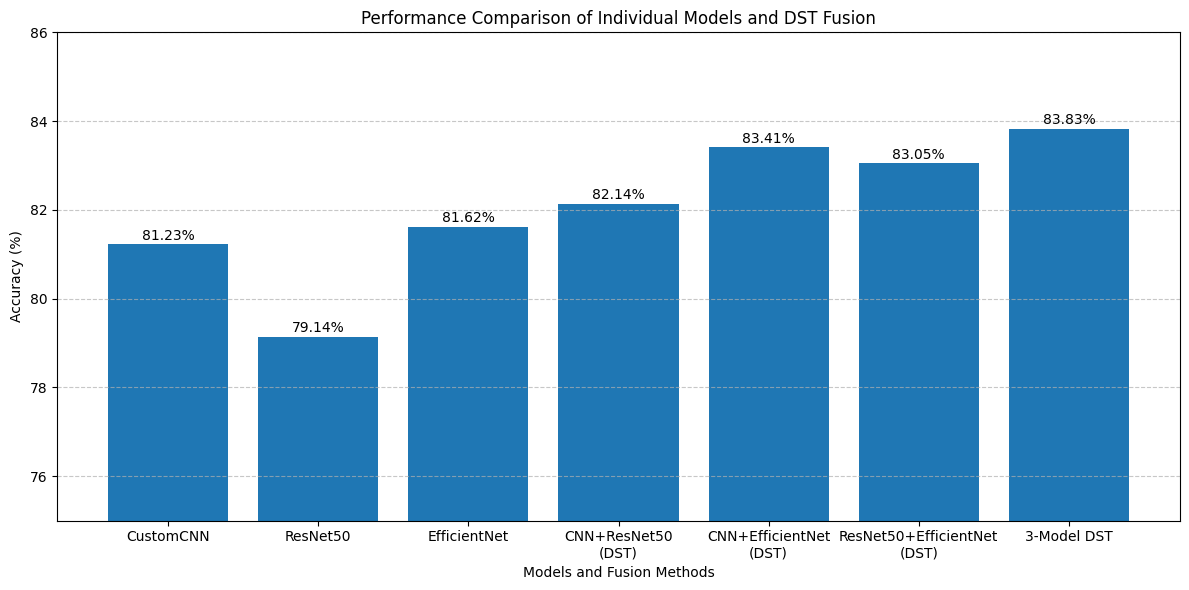

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

methods = [
    "CustomCNN",
    "ResNet50",
    "EfficientNet",
    "CNN+ResNet50\n(DST)",
    "CNN+EfficientNet\n(DST)",
    "ResNet50+EfficientNet\n(DST)",
    "3-Model DST"
]

accuracies = [
    81.23,
    79.14,
    81.62,
    82.14,
    83.41,
    83.05,
    83.83
]

plt.figure(figsize=(12,6))

bars = plt.bar(methods, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models and Fusion Methods")
plt.title("Performance Comparison of Individual Models and DST Fusion")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}%",
        ha='center'
    )

plt.ylim(75, 86)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("accuracy_comparison.png", dpi=300)

plt.show()

In [36]:
plt.savefig(
    "/kaggle/working/accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

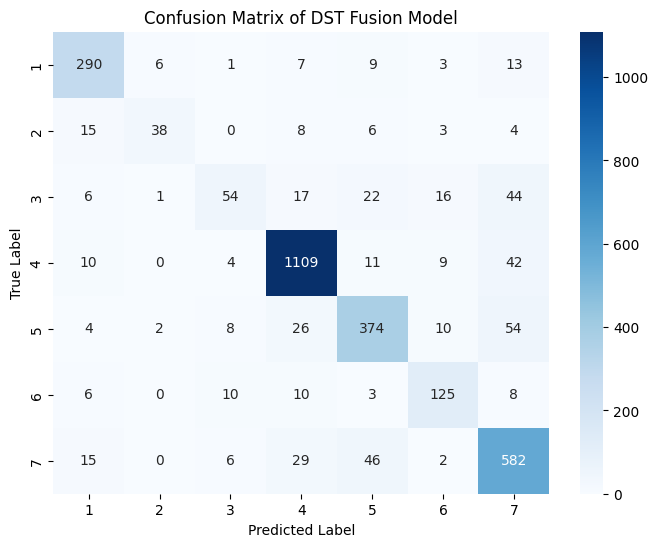

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, dst3_predictions)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['1','2','3','4','5','6','7'],
    yticklabels=['1','2','3','4','5','6','7']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix of DST Fusion Model")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        dst3_predictions,
        target_names=[
            "Surprise",
            "Fear",
            "Disgust",
            "Happy",
            "Sad",
            "Anger",
            "Neutral"
        ]
    )
)

              precision    recall  f1-score   support

    Surprise       0.84      0.88      0.86       329
        Fear       0.81      0.51      0.63        74
     Disgust       0.65      0.34      0.44       160
       Happy       0.92      0.94      0.93      1185
         Sad       0.79      0.78      0.79       478
       Anger       0.74      0.77      0.76       162
     Neutral       0.78      0.86      0.82       680

    accuracy                           0.84      3068
   macro avg       0.79      0.73      0.75      3068
weighted avg       0.83      0.84      0.83      3068



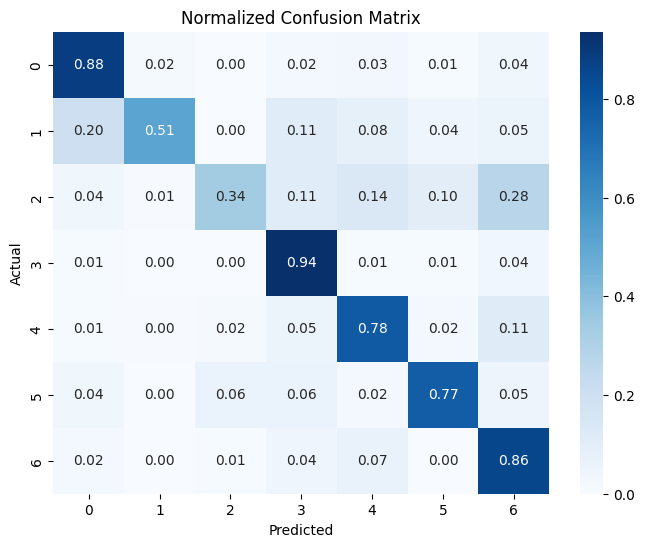

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

cm = confusion_matrix(true_labels, dst3_predictions)

cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
import pandas as pd
import numpy as np

cm = confusion_matrix(true_labels, dst3_predictions)

class_acc = cm.diagonal() / cm.sum(axis=1)

df = pd.DataFrame({
    "Emotion": [
        "Surprise",
        "Fear",
        "Disgust",
        "Happy",
        "Sad",
        "Anger",
        "Neutral"
    ],
    "Accuracy (%)": class_acc*100
})

print(df)

    Emotion  Accuracy (%)
0  Surprise     88.145897
1      Fear     51.351351
2   Disgust     33.750000
3     Happy     93.586498
4       Sad     78.242678
5     Anger     77.160494
6   Neutral     85.588235


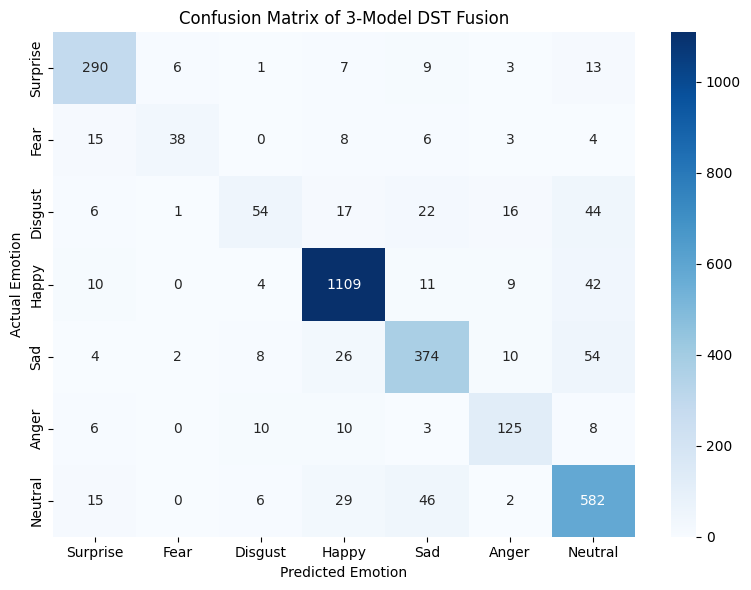

Confusion Matrix Saved Successfully!


In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, dst3_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Surprise',
        'Fear',
        'Disgust',
        'Happy',
        'Sad',
        'Anger',
        'Neutral'
    ],
    yticklabels=[
        'Surprise',
        'Fear',
        'Disgust',
        'Happy',
        'Sad',
        'Anger',
        'Neutral'
    ]
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Confusion Matrix of 3-Model DST Fusion")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix_dst3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion Matrix Saved Successfully!")

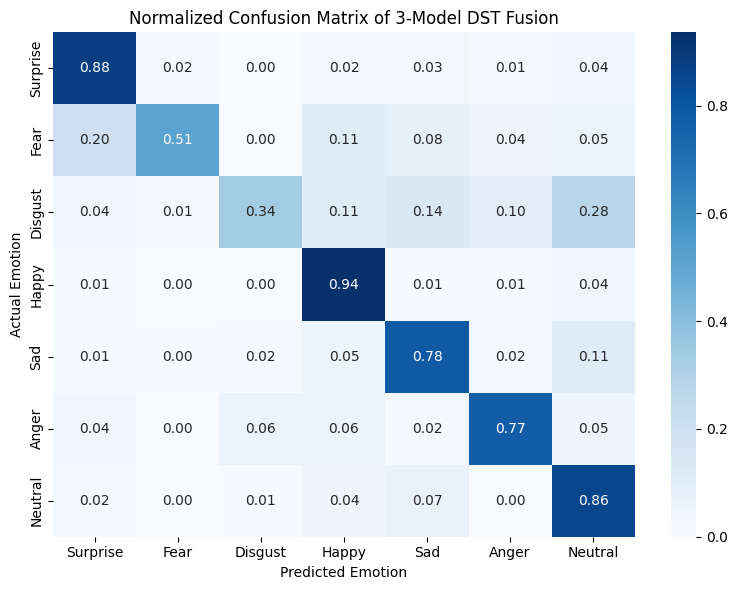

Normalized Confusion Matrix Saved Successfully!


In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, dst3_predictions)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[
        'Surprise',
        'Fear',
        'Disgust',
        'Happy',
        'Sad',
        'Anger',
        'Neutral'
    ],
    yticklabels=[
        'Surprise',
        'Fear',
        'Disgust',
        'Happy',
        'Sad',
        'Anger',
        'Neutral'
    ]
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Normalized Confusion Matrix of 3-Model DST Fusion")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/normalized_confusion_matrix_dst3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Normalized Confusion Matrix Saved Successfully!")

In [43]:
import pandas as pd

table = pd.DataFrame({
    "Iteration":[1,2,3,4,5],
    "ResNet50":[79.14,79.14,79.14,79.14,79.14],
    "EfficientNet":[81.62,81.62,81.62,81.62,81.62],
    "CustomCNN":[81.23,81.23,81.23,81.23,81.23],
    "DST Fusion":[83.83,83.83,83.83,83.83,83.83]
})

print(table)

   Iteration  ResNet50  EfficientNet  CustomCNN  DST Fusion
0          1     79.14         81.62      81.23       83.83
1          2     79.14         81.62      81.23       83.83
2          3     79.14         81.62      81.23       83.83
3          4     79.14         81.62      81.23       83.83
4          5     79.14         81.62      81.23       83.83


Dataset Label: 4


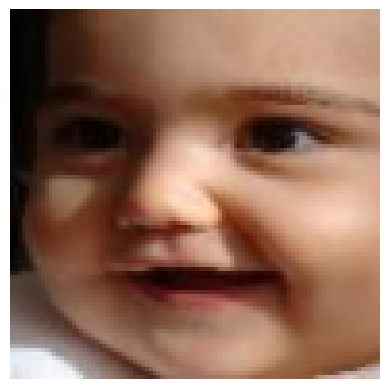

Image Index: 860


In [44]:
import random
import matplotlib.pyplot as plt

idx = random.randint(0, len(cnn_test_dataset)-1)

img, label = cnn_test_dataset[idx]

print("Dataset Label:", cnn_test_dataset.classes[label])

plt.imshow(img.permute(1,2,0)*0.5+0.5)
plt.axis("off")
plt.show()

print("Image Index:", idx)

In [45]:
path, label = cnn_test_dataset.samples[idx]

print("Image Path:", path)
print("True Label:", cnn_test_dataset.classes[label])

Image Path: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/4/test_0505_aligned.jpg
True Label: 4


In [46]:
from PIL import Image
import torch
import numpy as np

emotion_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

image_path = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/4/test_0505_aligned.jpg"

img = Image.open(image_path).convert("RGB")

# ---------- CNN ----------
cnn_img = cnn_transform(img).unsqueeze(0).to(device)

cnn_model.eval()
with torch.no_grad():
    cnn_out = cnn_model(cnn_img)
    cnn_prob = torch.softmax(cnn_out, dim=1).cpu().numpy()[0]

# ---------- ResNet ----------
resnet_img = resnet_transform(img).unsqueeze(0).to(device)

resnet_model.eval()
with torch.no_grad():
    res_out = resnet_model(resnet_img)
    res_prob = torch.softmax(res_out, dim=1).cpu().numpy()[0]

# ---------- EfficientNet ----------
eff_img = eff_transform(img).unsqueeze(0).to(device)

eff_model.eval()
with torch.no_grad():
    eff_out = eff_model(eff_img)
    eff_prob = torch.softmax(eff_out, dim=1).cpu().numpy()[0]

print("CNN Prediction       :", emotion_names[np.argmax(cnn_prob)])
print("ResNet50 Prediction  :", emotion_names[np.argmax(res_prob)])
print("EffNet Prediction    :", emotion_names[np.argmax(eff_prob)])

CNN Prediction       : Happy
ResNet50 Prediction  : Happy
EffNet Prediction    : Happy


In [47]:
emotion_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

m1 = probs_to_bba(cnn_prob)
m2 = probs_to_bba(res_prob)
m3 = probs_to_bba(eff_prob)

fused12 = orthogonal_sum(m1, m2)
fused123 = orthogonal_sum(fused12, m3)

dst_prob = np.array([
    fused123.get(frozenset([i]), 0)
    for i in range(7)
])

dst_pred = np.argmax(dst_prob)

print("DST Prediction :", emotion_names[dst_pred])

DST Prediction : Happy


In [48]:
import pandas as pd

df = pd.DataFrame({
    "Emotion": emotion_names,
    "CNN": cnn_prob,
    "ResNet50": res_prob,
    "EfficientNet": eff_prob,
    "DST Fusion": dst_prob
})

df = df.sort_values(
    by="DST Fusion",
    ascending=False
)

print(df.to_string(index=False))

 Emotion      CNN     ResNet50  EfficientNet   DST Fusion
   Happy 0.851449 9.976659e-01      0.999737 1.000000e+00
Surprise 0.034852 7.447524e-04      0.000029 8.789335e-10
 Neutral 0.010208 1.563688e-03      0.000014 2.695598e-10
     Sad 0.055785 1.070735e-05      0.000170 1.197379e-10
    Fear 0.033197 1.084293e-05      0.000040 1.709377e-11
 Disgust 0.008232 3.974058e-06      0.000007 2.752102e-13
   Anger 0.006277 2.162055e-07      0.000002 3.549404e-15


In [49]:
pd.set_option('display.float_format', '{:.10f}'.format)

print(df.to_string(index=False))

 Emotion          CNN     ResNet50  EfficientNet   DST Fusion
   Happy 0.8514491916 0.9976658821  0.9997369647 1.0000001428
Surprise 0.0348520987 0.0007447524  0.0000287571 0.0000000009
 Neutral 0.0102084735 0.0015636876  0.0000143408 0.0000000003
     Sad 0.0557846278 0.0000107073  0.0001702412 0.0000000001
    Fear 0.0331965946 0.0000108429  0.0000403299 0.0000000000
 Disgust 0.0082319146 0.0000039741  0.0000071443 0.0000000000
   Anger 0.0062771598 0.0000002162  0.0000022210 0.0000000000


In [50]:
df_rounded = df.copy()

for col in ["CNN", "ResNet50", "EfficientNet", "DST Fusion"]:
    df_rounded[col] = df_rounded[col].round(4)

print(df_rounded.to_string(index=False))

 Emotion          CNN     ResNet50  EfficientNet   DST Fusion
   Happy 0.8514000177 0.9976999760  0.9997000098 1.0000000000
Surprise 0.0348999985 0.0007000000  0.0000000000 0.0000000000
 Neutral 0.0102000004 0.0016000000  0.0000000000 0.0000000000
     Sad 0.0557999983 0.0000000000  0.0002000000 0.0000000000
    Fear 0.0331999995 0.0000000000  0.0000000000 0.0000000000
 Disgust 0.0082000000 0.0000000000  0.0000000000 0.0000000000
   Anger 0.0063000000 0.0000000000  0.0000000000 0.0000000000


In [51]:
image_path = "/kaggle/input/datasets/ankansamanta980/facial-emotion/happyimg.jpg"

In [52]:
from PIL import Image
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

emotion_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

image_path = "/kaggle/input/datasets/ankansamanta980/facial-emotion/happyimg.jpg"

img = Image.open(image_path).convert("RGB")

# ---------- CNN ----------
cnn_img = cnn_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    cnn_prob = torch.softmax(
        cnn_model(cnn_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- ResNet ----------
res_img = resnet_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    res_prob = torch.softmax(
        resnet_model(res_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- EfficientNet ----------
eff_img = eff_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    eff_prob = torch.softmax(
        eff_model(eff_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- DST ----------
m1 = probs_to_bba(cnn_prob)
m2 = probs_to_bba(res_prob)
m3 = probs_to_bba(eff_prob)

fused12 = orthogonal_sum(m1, m2)
fused123 = orthogonal_sum(fused12, m3)

dst_prob = np.array([
    fused123.get(frozenset([i]), 0)
    for i in range(7)
])

# ---------- Table ----------
df = pd.DataFrame({
    "Emotion": emotion_names,
    "CNN": cnn_prob,
    "ResNet50": res_prob,
    "EfficientNet": eff_prob,
    "DST Fusion": dst_prob
})

df = df.sort_values(
    by="DST Fusion",
    ascending=False
)

pd.set_option(
    'display.float_format',
    '{:.6f}'.format
)

print(df)

# ---------- Final Prediction ----------
print("\nCNN Prediction:",
      emotion_names[np.argmax(cnn_prob)])

print("ResNet50 Prediction:",
      emotion_names[np.argmax(res_prob)])

print("EfficientNet Prediction:",
      emotion_names[np.argmax(eff_prob)])

print("DST Prediction:",
      emotion_names[np.argmax(dst_prob)])

    Emotion      CNN  ResNet50  EfficientNet  DST Fusion
1      Fear 0.031598  0.897406      0.329836    0.656602
4       Sad 0.877868  0.087182      0.061889    0.332524
5     Anger 0.019287  0.013643      0.587688    0.010856
3     Happy 0.037549  0.000584      0.003292    0.000005
0  Surprise 0.007904  0.000797      0.005820    0.000003
2   Disgust 0.015583  0.000272      0.006125    0.000002
6   Neutral 0.010212  0.000117      0.005349    0.000000

CNN Prediction: Sad
ResNet50 Prediction: Fear
EfficientNet Prediction: Anger
DST Prediction: Fear


In [27]:
image_path = "/kaggle/input/datasets/ankansamanta980/surprise-image/surprise_img.jpeg"

In [28]:
from PIL import Image
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

emotion_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

image_path = "/kaggle/input/datasets/ankansamanta980/surprise-image/surprise_img.jpeg"

img = Image.open(image_path).convert("RGB")

# ---------- CNN ----------
cnn_img = cnn_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    cnn_prob = torch.softmax(
        cnn_model(cnn_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- ResNet ----------
res_img = resnet_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    res_prob = torch.softmax(
        resnet_model(res_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- EfficientNet ----------
eff_img = eff_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    eff_prob = torch.softmax(
        eff_model(eff_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- DST ----------
m1 = probs_to_bba(cnn_prob)
m2 = probs_to_bba(res_prob)
m3 = probs_to_bba(eff_prob)

fused12 = orthogonal_sum(m1, m2)
fused123 = orthogonal_sum(fused12, m3)

dst_prob = np.array([
    fused123.get(frozenset([i]), 0)
    for i in range(7)
])

# ---------- Table ----------
df = pd.DataFrame({
    "Emotion": emotion_names,
    "CNN": cnn_prob,
    "ResNet50": res_prob,
    "EfficientNet": eff_prob,
    "DST Fusion": dst_prob
})

df = df.sort_values(
    by="DST Fusion",
    ascending=False
)

pd.set_option(
    'display.float_format',
    '{:.6f}'.format
)

print(df)

# ---------- Final Prediction ----------
print("\nCNN Prediction:",
      emotion_names[np.argmax(cnn_prob)])

print("ResNet50 Prediction:",
      emotion_names[np.argmax(res_prob)])

print("EfficientNet Prediction:",
      emotion_names[np.argmax(eff_prob)])

print("DST Prediction:",
      emotion_names[np.argmax(dst_prob)])

    Emotion      CNN  ResNet50  EfficientNet  DST Fusion
5     Anger 0.139516  0.970951      0.040004    0.860872
0  Surprise 0.229675  0.006141      0.520994    0.116738
1      Fear 0.083895  0.003611      0.430560    0.020719
4       Sad 0.426881  0.008481      0.002724    0.001567
3     Happy 0.075628  0.001266      0.004082    0.000062
2   Disgust 0.025810  0.008750      0.001084    0.000039
6   Neutral 0.018594  0.000800      0.000551    0.000001

CNN Prediction: Sad
ResNet50 Prediction: Anger
EfficientNet Prediction: Surprise
DST Prediction: Anger


In [29]:
from PIL import Image
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

emotion_names = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral"
]

image_path = "/kaggle/input/datasets/ankansamanta980/sur-img/surprise_img.jpeg"

img = Image.open(image_path).convert("RGB")

# ---------- CNN ----------
cnn_img = cnn_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    cnn_prob = torch.softmax(
        cnn_model(cnn_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- ResNet ----------
res_img = resnet_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    res_prob = torch.softmax(
        resnet_model(res_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- EfficientNet ----------
eff_img = eff_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    eff_prob = torch.softmax(
        eff_model(eff_img),
        dim=1
    ).cpu().numpy()[0]

# ---------- DST ----------
m1 = probs_to_bba(cnn_prob)
m2 = probs_to_bba(res_prob)
m3 = probs_to_bba(eff_prob)

fused12 = orthogonal_sum(m1, m2)
fused123 = orthogonal_sum(fused12, m3)

dst_prob = np.array([
    fused123.get(frozenset([i]), 0)
    for i in range(7)
])

# ---------- Table ----------
df = pd.DataFrame({
    "Emotion": emotion_names,
    "CNN": cnn_prob,
    "ResNet50": res_prob,
    "EfficientNet": eff_prob,
    "DST Fusion": dst_prob
})

df = df.sort_values(
    by="DST Fusion",
    ascending=False
)

pd.set_option(
    'display.float_format',
    '{:.6f}'.format
)

print(df)

# ---------- Final Prediction ----------
print("\nCNN Prediction:",
      emotion_names[np.argmax(cnn_prob)])

print("ResNet50 Prediction:",
      emotion_names[np.argmax(res_prob)])

print("EfficientNet Prediction:",
      emotion_names[np.argmax(eff_prob)])

print("DST Prediction:",
      emotion_names[np.argmax(dst_prob)])

    Emotion      CNN  ResNet50  EfficientNet  DST Fusion
0  Surprise 0.669005  0.518213      0.463432    0.944121
5     Anger 0.075287  0.238325      0.492027    0.051878
1      Fear 0.176092  0.122017      0.028430    0.003590
4       Sad 0.052476  0.114983      0.011583    0.000411
2   Disgust 0.014379  0.000560      0.003208    0.000000
3     Happy 0.005346  0.004935      0.000867    0.000000
6   Neutral 0.007414  0.000967      0.000454    0.000000

CNN Prediction: Surprise
ResNet50 Prediction: Surprise
EfficientNet Prediction: Anger
DST Prediction: Surprise
